Rows: 48842  test: 12211 ; gender excluded from features
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      9289
        >50K       0.56      0.83      0.67      2922

    accuracy                           0.80     12211
   macro avg       0.75      0.81      0.76     12211
weighted avg       0.85      0.80      0.81     12211

Accuracy/precision/recall/AUC: 0.8014085660470068 0.556930126002291 0.8319644079397673 0.9019611635762688
Baseline subgroup metrics: {'privileged_rate': 0.4587932303164091, 'unprivileged_rate': 0.15380823268424945, 'disparate_impact': 0.3352452096517963, 'TPR_privileged': 0.8545970028351559, 'TPR_unprivileged': 0.7086092715231788, 'FPR_privileged': 0.2868953386103782, 'FPR_unprivileged': 0.08407325194228635}


AIF360 training DI before: 0.356626250648345


After reweighing test metrics: {'privileged_rate': 0.2108167770419426, 'unprivileged_rate': 0.12373675129405964, 'disparate_impact': 0.5869397731540211, 'TPR_privileged': 0.5321992709599028, 'TPR_unprivileged': 0.6534216335540839, 'FPR_privileged': 0.0712401055408971, 'FPR_unprivileged': 0.05715871254162042}
Test DI before -> after: 0.335 -> 0.587
Reweighed accuracy/precision/recall/AUC: 0.8425190402096471 0.724898694281855 0.5509924709103354 0.896393760653512


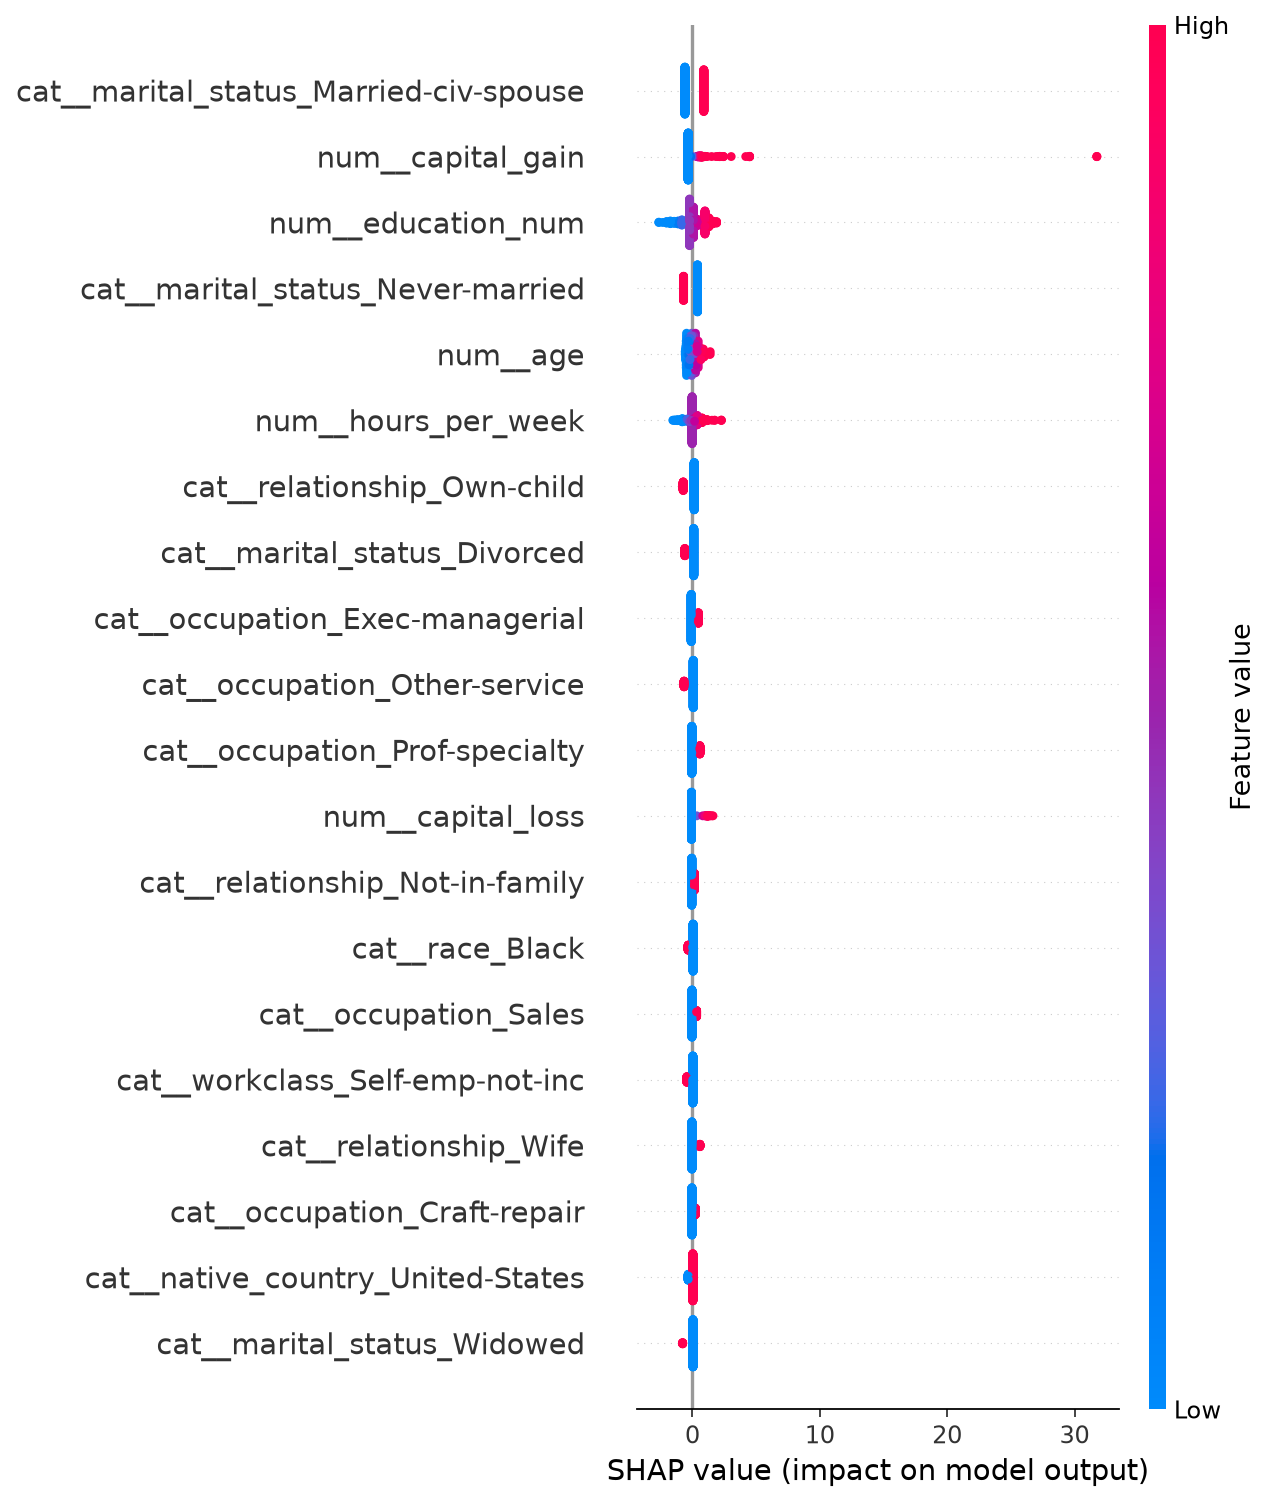

SHAP plot: C:\cynarisis-internship\outputs\w4d6_responsible_ai\adult_income_shap_summary.png


Model card PDF: C:\cynarisis-internship\outputs\w4d6_responsible_ai\model_card.pdf
Model card Markdown: C:\cynarisis-internship\outputs\w4d6_responsible_ai\model_card.md


In [1]:
from pathlib import Path
import warnings, logging, numpy as np, pandas as pd
from html import escape
from IPython.display import display, Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,roc_auc_score
ROOT=Path.cwd().parent if Path.cwd().name=="week4_Notebooks" else Path.cwd(); OUT=ROOT/"outputs"/"w4d6_responsible_ai"; OUT.mkdir(parents=True,exist_ok=True); SEED=42
try:
 from importlib import import_module
 fetch_ucirepo=import_module("ucimlrepo").fetch_ucirepo
 ds=fetch_ucirepo(id=2); df=ds.data.features.copy(); df["income"]=ds.data.targets.iloc[:,0].astype(str).str.strip().str.rstrip(".")
except Exception as ue:
 try:
  from sklearn.datasets import fetch_openml
  b=fetch_openml("adult",version=2,as_frame=True,parser="auto",data_home=str(OUT/"openml_cache")); df=b.frame.copy(); tc=b.target.name if getattr(b.target,"name",None) in b.frame.columns else ("class" if "class" in b.frame else b.frame.columns[-1]); df["income"]=df[tc].astype(str).str.strip().str.rstrip("."); df=df.drop(columns=[tc]) if tc!="income" else df
 except Exception as oe: raise RuntimeError(f"Adult dataset unavailable. Install ucimlrepo and allow internet. UCI={ue}; OpenML={oe}")
df.columns=[str(c).strip().lower().replace("-","_").replace(" ","_") for c in df.columns]; sex=next((c for c in df if c in ("sex","gender")),None)
if sex is None or "income" not in df: raise ValueError(f"Missing income/gender columns: {list(df.columns)}")
g=df[sex].astype(str).str.strip().str.lower(); privileged=g.isin(["male","m","1","true"])
if privileged.nunique()!=2: raise ValueError("Need two gender groups for audit")
y=df.income.astype(str).str.strip().str.rstrip(".").str.lower().isin([">50k","1","true"]).astype(int); X=df.drop(columns=["income",sex])
for c in X.columns:
 if pd.api.types.is_object_dtype(X[c].dtype) or pd.api.types.is_string_dtype(X[c].dtype): X[c]=X[c].astype(str).str.strip().replace({"?":np.nan,"nan":np.nan,"<NA>":np.nan})
nums=list(X.select_dtypes(include=["number"]).columns); cats=[c for c in X if c not in nums]
prep=ColumnTransformer([("num",Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler())]),nums),("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("ohe",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cats)])
Xtr,Xte,ytr,yte,gtr,gte=train_test_split(X,y,privileged,test_size=.25,random_state=SEED,stratify=y); Xtrt=prep.fit_transform(Xtr); Xtet=prep.transform(Xte)
# OneHotEncoder is configured for dense output, so keep transformed features as NumPy arrays.
Xtrt=np.asarray(Xtrt); Xtet=np.asarray(Xtet); names=prep.get_feature_names_out()
model=LogisticRegression(max_iter=1000,class_weight="balanced",random_state=SEED).fit(Xtrt,ytr); prob=model.predict_proba(Xtet)[:,1]; pred=(prob>=.5).astype(int)
def rates(labels,preds,groups):
 labels=np.asarray(labels); preds=np.asarray(preds); groups=np.asarray(groups,dtype=bool); rp=preds[groups].mean(); ru=preds[~groups].mean()
 return {"privileged_rate":float(rp),"unprivileged_rate":float(ru),"disparate_impact":float(ru/rp) if rp else np.nan,"TPR_privileged":float(preds[(labels==1)&groups].mean()),"TPR_unprivileged":float(preds[(labels==1)&~groups].mean()),"FPR_privileged":float(preds[(labels==0)&groups].mean()),"FPR_unprivileged":float(preds[(labels==0)&~groups].mean())}
base=rates(yte,pred,gte); print("Rows:",len(df)," test:",len(yte),"; gender excluded from features"); print(classification_report(yte,pred,target_names=["<=50K",">50K"],zero_division=0)); print("Accuracy/precision/recall/AUC:",*[float(np.asarray(v).item()) for v in (accuracy_score(yte,pred),precision_score(yte,pred,zero_division=0),recall_score(yte,pred,zero_division=0),roc_auc_score(yte,prob))]); print("Baseline subgroup metrics:",base)
mit=None
try:
 from importlib import import_module
 # AIF360 logs warnings for optional algorithms that this notebook does not use.
 class _AIF360OptionalWarningFilter(logging.Filter):
  def filter(self, record):
   message=record.getMessage()
   optional_dependency=any(name in message for name in ("tensorflow", "fairlearn", "inFairness"))
   return not (record.name == "root" and "will be unavailable" in message and optional_dependency)
 _aif360_warning_filter=_AIF360OptionalWarningFilter()
 _root_logger=logging.getLogger()
 _root_logger.addFilter(_aif360_warning_filter)
 try:
  BinaryLabelDataset=import_module("aif360.datasets").BinaryLabelDataset
  BinaryLabelDatasetMetric=import_module("aif360.metrics").BinaryLabelDatasetMetric
  Reweighing=import_module("aif360.algorithms.preprocessing").Reweighing
 finally:
  _root_logger.removeFilter(_aif360_warning_filter)
 aud=pd.DataFrame({"label":ytr.to_numpy().astype(float),"gender_audit":gtr.astype(int).to_numpy().astype(float)}); bld=BinaryLabelDataset(df=aud,label_names=["label"],protected_attribute_names=["gender_audit"],favorable_label=1.,unfavorable_label=0.); un=[{"gender_audit":0.}]; pr=[{"gender_audit":1.}]
 print("AIF360 training DI before:",BinaryLabelDatasetMetric(bld,unprivileged_groups=un,privileged_groups=pr).disparate_impact()); weights=Reweighing(unprivileged_groups=un,privileged_groups=pr).fit_transform(bld)
 mitigated=LogisticRegression(max_iter=1000,random_state=SEED).fit(Xtrt,ytr,sample_weight=weights.instance_weights); mp=mitigated.predict_proba(Xtet)[:,1]; my=(mp>=.5).astype(int); mit=rates(yte,my,gte); print("After reweighing test metrics:",mit); print(f"Test DI before -> after: {float(np.asarray(base['disparate_impact']).item()):.3f} -> {float(np.asarray(mit['disparate_impact']).item()):.3f}"); print("Reweighed accuracy/precision/recall/AUC:",*[float(np.asarray(v).item()) for v in (accuracy_score(yte,my),precision_score(yte,my,zero_division=0),recall_score(yte,my,zero_division=0),roc_auc_score(yte,mp))])
except ImportError: print("Install aif360 for AIF360 metric and Reweighing")
except Exception as e: warnings.warn(f"AIF360 skipped: {e}")
try:
 import importlib
 shap=importlib.import_module("shap")
 explainer=shap.LinearExplainer(model,Xtrt[:100]); sv=explainer(Xtet[:500]); shap.summary_plot(sv,features=Xtet[:500],feature_names=names,max_display=20,show=False); sp=OUT/"adult_income_shap_summary.png"; plt.tight_layout(); plt.savefig(sp,dpi=160,bbox_inches="tight"); plt.close(); display(Image(filename=str(sp))); print("SHAP plot:",sp)
except ImportError: print("Install shap to generate SHAP summary plot")
except Exception as e: warnings.warn(f"SHAP skipped: {e}")
acc=accuracy_score(yte,pred); precision=precision_score(yte,pred,zero_division=0); recall=recall_score(yte,pred,zero_division=0); auc=roc_auc_score(yte,prob); ditxt=f"{base['disparate_impact']:.3f}"; mitxt=f"Reweighed test DI: {mit['disparate_impact']:.3f}." if mit else "Reweighing unavailable (AIF360 missing or failed)."
lines=["# Model Card ? Adult Income Logistic Regression","",f"**Version/owner:** Week 4 educational audit / Student. **Seed:** {SEED}.","", "**Model details:** Logistic Regression with class balancing; numeric median imputation and scaling; categorical mode imputation and one-hot encoding. Gender is excluded from predictors and retained for audit only.","", "**Intended use:** Educational fairness and explainability demonstration on UCI Adult Census Income. Not intended for hiring, lending, benefits, or individual economic decisions.","", "**Factors and data:** Historical US census data includes age, education, occupation, hours, and demographics; labels may encode structural inequity. Stratified 75/25 train/test split; test size "+str(len(yte))+". Preprocessing fit on training data only.","", f"**Metrics:** Accuracy {acc:.3f}; positive-class precision {precision:.3f}; recall {recall:.3f}; ROC-AUC {auc:.3f}; test disparate impact (unprivileged/privileged selection rate) {ditxt}. {mitxt}","", "**Ethical considerations and caveats:** The old US dataset is not representative of present-day or Indian populations. Binary sex coding excludes gender diversity, and aggregate metrics hide intersectional harms. Demographic parity, equalized odds, and individual fairness encode different goals. SHAP describes model behavior, not causation. Reweighing does not establish fairness. Do not use for consequential decisions; require independent subgroup evaluation, privacy and domain review, monitoring, meaningful human review, and appeal mechanisms."]
card="\n".join(lines); md=OUT/"model_card.md"; md.write_text(card,encoding="utf-8")
try:
 from importlib import import_module
 pages=import_module("reportlab.lib.pagesizes"); platypus=import_module("reportlab.platypus"); styles_module=import_module("reportlab.lib.styles"); units=import_module("reportlab.lib.units"); colors=import_module("reportlab.lib.colors")
 SimpleDocTemplate=platypus.SimpleDocTemplate; Paragraph=platypus.Paragraph; Spacer=platypus.Spacer; getSampleStyleSheet=styles_module.getSampleStyleSheet; ParagraphStyle=styles_module.ParagraphStyle; letter=pages.letter; inch=units.inch
 pdf=OUT/"model_card.pdf"; doc=SimpleDocTemplate(str(pdf),pagesize=letter,leftMargin=.6*inch,rightMargin=.6*inch,topMargin=.5*inch,bottomMargin=.5*inch); sty=getSampleStyleSheet(); body=ParagraphStyle("BodySmall",parent=sty["BodyText"],fontSize=8,leading=9.5,spaceAfter=4); title=ParagraphStyle("TitleSmall",parent=sty["Title"],fontSize=15,textColor=colors.HexColor("#17324d"),spaceAfter=6); story=[]
 for i,p in enumerate(lines): story += [Paragraph(escape(p.replace("**", "")),title if i==0 else body),Spacer(1,2)]
 doc.build(story); print("Model card PDF:",pdf)
except Exception as e: warnings.warn(f"PDF generation skipped ({e}); Markdown model card saved")
print("Model card Markdown:",md)
